In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import random

/home/fahmialfayadh/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (4, 12), (4, 13), (4, 14), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (5, 14), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9), (6, 10), (6, 11), (6, 12), (6, 13), (6, 14), (7, 0), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (7, 8), (7, 9), (7, 10), (7, 11), (7, 12), (7, 13), (7, 14),

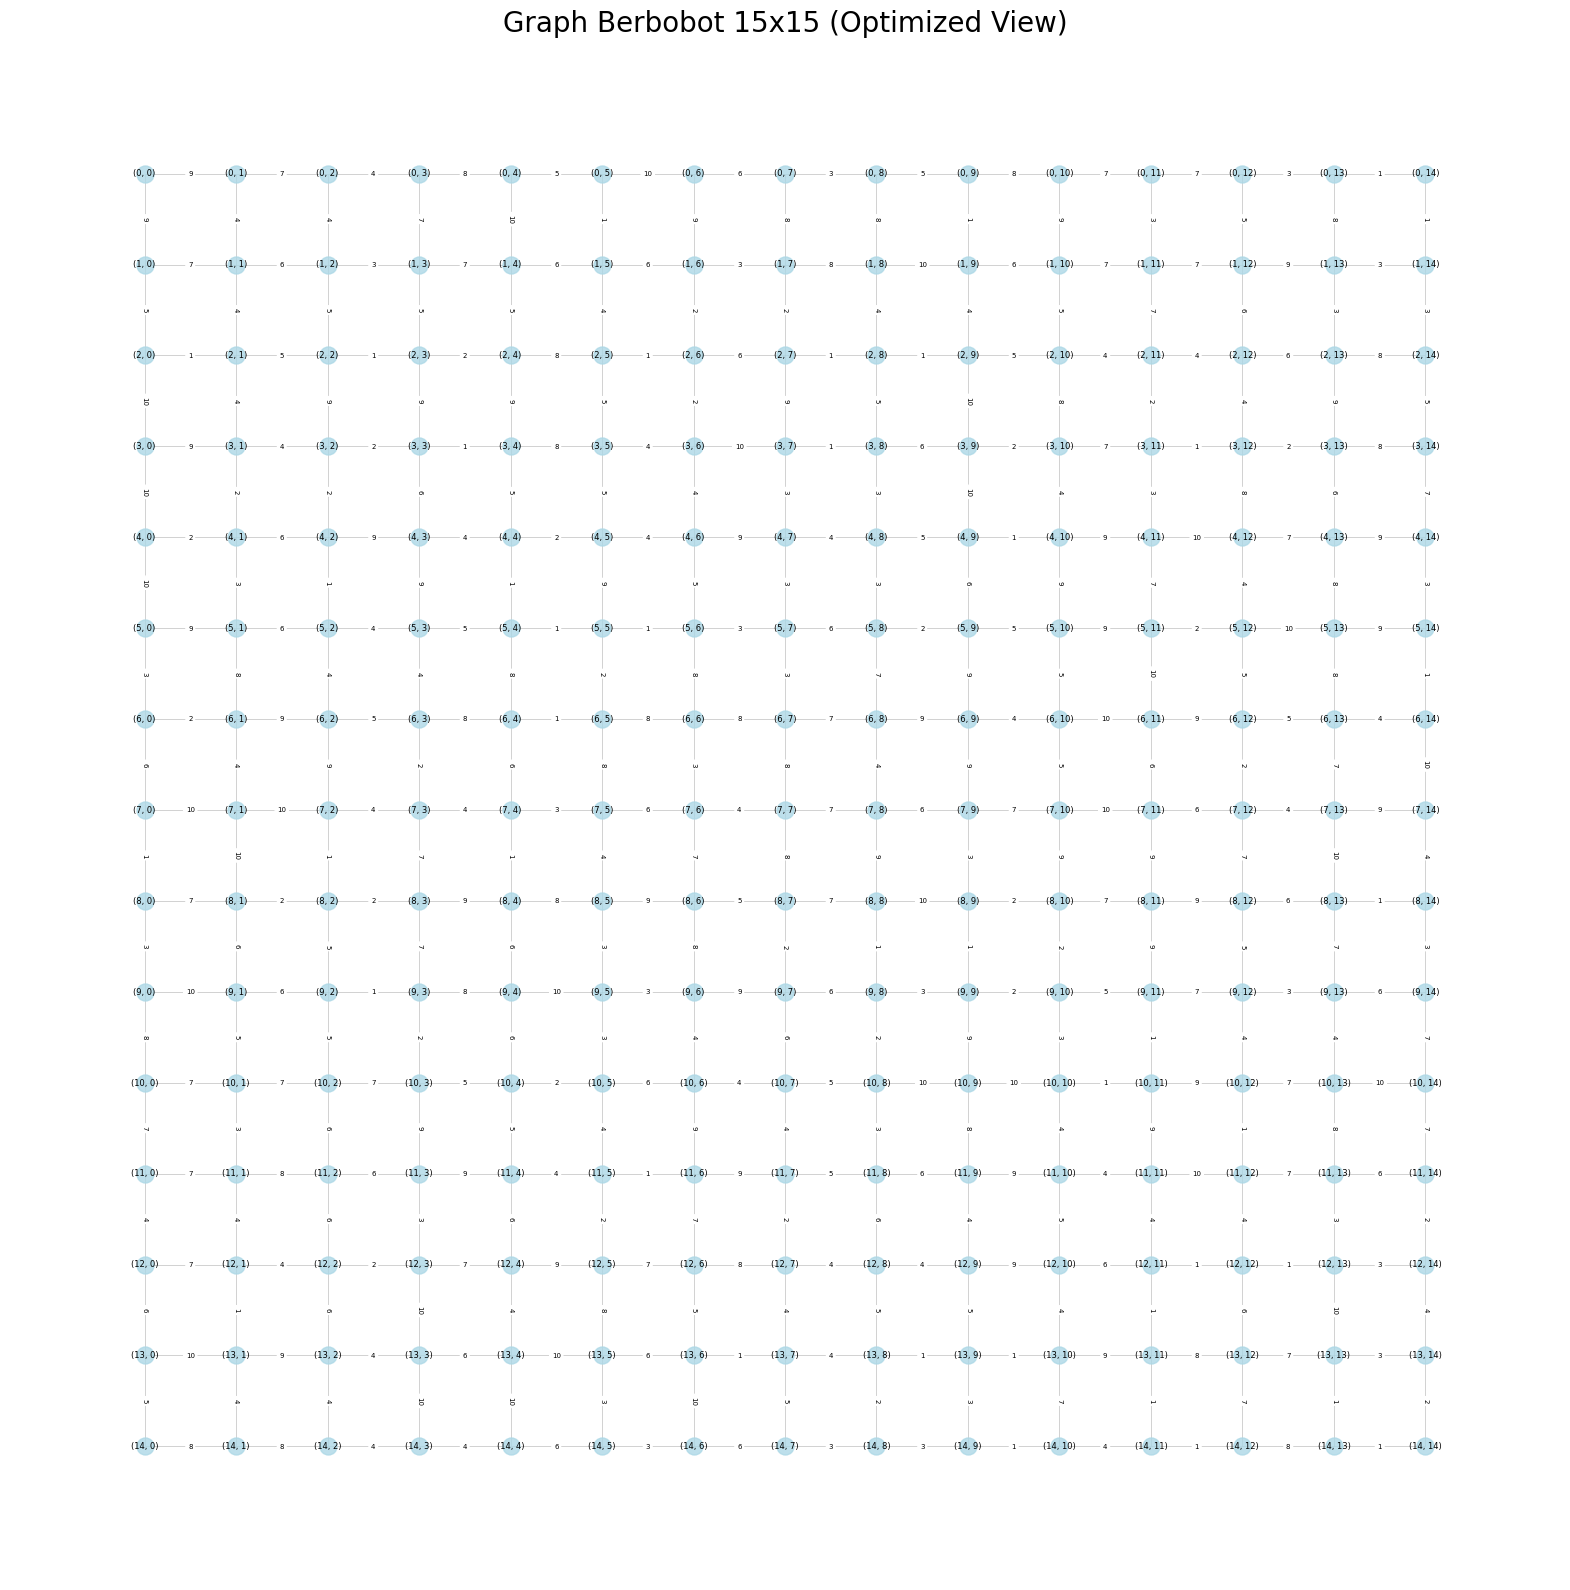

In [4]:
# buat adjacency graph berbobot 15 * 15
G = nx.grid_2d_graph(15, 15)
for (u, v) in G.edges():
    G.edges[u, v]['weight'] = random.randint(1, 10)
print(G.nodes())
print(G.edges())
print(G.edges(data=True))


# 2. Atur Ukuran Figure (PENTING: Gunakan ukuran besar seperti 20x20)
plt.figure(figsize=(20, 20))

# 3. Posisi node
pos = {(x, y): (y, -x) for x, y in G.nodes()}

# 4. Gambar Node dengan ukuran kecil
nx.draw_networkx_nodes(G, pos, 
                       node_color='lightblue', 
                       node_size=150,  # Ukuran node diperkecil
                       alpha=0.8)

# 5. Gambar Edge dengan garis tipis
nx.draw_networkx_edges(G, pos, 
                       width=0.5,      # Garis lebih tipis
                       edge_color='gray', 
                       alpha=0.5)

# 6. Gambar Label Node dengan font kecil
nx.draw_networkx_labels(G, pos, 
                        font_size=6,   # Font sangat kecil agar tidak overlap
                        font_family='sans-serif')

# 7. Gambar Label Bobot (Edge Labels)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, 
                             edge_labels=edge_labels, 
                             font_size=5,      # Font bobot lebih kecil lagi
                             label_pos=0.5)

plt.title("Graph Berbobot 15x15 (Optimized View)", fontsize=20)
plt.axis('off') # Menghilangkan axis koordinat
plt.show()

## implementasi algoritma djikstra

In [5]:
## implementasi algoritma djikstra
import heapq
import pandas as pd

print("===="*20)
print("===="*20)
print()
print("Log Progress Dijkstra:")
      

def dijkstra(graph, start):
    # inisialisasi jarak dan path
    distances = {node: float('infinity') for node in graph.nodes()}
    distances[start] = 0
    previous = {node: None for node in graph.nodes()}
    
    # inisialisasi antrian prioritas
    queue = [(0, start)] # (jarak, node)
    
    # ini buat log progress untuk ditampilkan di tabel
    log = []
    step = 0
    while queue:
        current_distance, current_node = heapq.heappop(queue) #pop node dengan jarak terkecil
        
        if current_distance > distances[current_node]: #cek apakah jarak yg diambil lebih besar dari jarak yg sudah diketahui, jika iya maka
            continue                                           # node tersebut sudah diproses dan tidak perlu diproses lagi
        
        
        '''====================== ini buat log progress ======================'''
        # bobot neighbors
        nb_weights = {str(nb): graph.edges[current_node, nb]['weight'] for nb in graph.neighbors(current_node)}
        
        #snapshot:step, node terpilinh,, jarak node, bobot neighbors
        snapshot = {
            'Step': step,
            'Node_Terpilih': str(current_node),
            'Jarak_Node': current_distance,
            'Bobot_Neighbors': str(nb_weights)
        }

        # update 
        snapshot.update({str(node): distances[node] for node in graph.nodes()})
        log.append(snapshot)
        step += 1
        '''========================= end of log progress ========================='''

        for neighbor in graph.neighbors(current_node):
            weight = graph.edges[current_node, neighbor]['weight']
            distance = current_distance + weight
            
            if distance < distances[neighbor]: #jika jarak baru lebih kecil dari jarak yang sudah diketahui, update jarak dan path
                distances[neighbor] = distance #update jarak terkecil ke neighbor
                previous[neighbor] = current_node #update path menuju neighbor
                heapq.heappush(queue, (distance, neighbor)) # masukkan neighbor ke antrian dengan jarak baru


    df_full = pd.DataFrame(log)
    audit_table = pd.concat([df_full.head(10), df_full.tail(10)])
    
    # Pengaturan tampilan agar tidak berantakan di terminal
    pd.set_option('display.max_columns', 8) 
    pd.set_option('display.width', 1000)
    
    print(f"\n[TABEL AUDIT DIJKSTRA - {len(df_full)} TOTAL STEPS]")
    print(audit_table.to_string(index=False))
    return distances, previous, audit_table
# use case
start_node = (0, 0)  # titik awal
distances, previous, audit_table = dijkstra(G, start_node)

audit_table.head(10)






Log Progress Dijkstra:

[TABEL AUDIT DIJKSTRA - 225 TOTAL STEPS]
 Step Node_Terpilih  Jarak_Node                                               Bobot_Neighbors  (0, 0)  (0, 1)  (0, 2)  (0, 3)  (0, 4)  (0, 5)  (0, 6)  (0, 7)  (0, 8)  (0, 9)  (0, 10)  (0, 11)  (0, 12)  (0, 13)  (0, 14)  (1, 0)  (1, 1)  (1, 2)  (1, 3)  (1, 4)  (1, 5)  (1, 6)  (1, 7)  (1, 8)  (1, 9)  (1, 10)  (1, 11)  (1, 12)  (1, 13)  (1, 14)  (2, 0)  (2, 1)  (2, 2)  (2, 3)  (2, 4)  (2, 5)  (2, 6)  (2, 7)  (2, 8)  (2, 9)  (2, 10)  (2, 11)  (2, 12)  (2, 13)  (2, 14)  (3, 0)  (3, 1)  (3, 2)  (3, 3)  (3, 4)  (3, 5)  (3, 6)  (3, 7)  (3, 8)  (3, 9)  (3, 10)  (3, 11)  (3, 12)  (3, 13)  (3, 14)  (4, 0)  (4, 1)  (4, 2)  (4, 3)  (4, 4)  (4, 5)  (4, 6)  (4, 7)  (4, 8)  (4, 9)  (4, 10)  (4, 11)  (4, 12)  (4, 13)  (4, 14)  (5, 0)  (5, 1)  (5, 2)  (5, 3)  (5, 4)  (5, 5)  (5, 6)  (5, 7)  (5, 8)  (5, 9)  (5, 10)  (5, 11)  (5, 12)  (5, 13)  (5, 14)  (6, 0)  (6, 1)  (6, 2)  (6, 3)  (6, 4)  (6, 5)  (6, 6)  (6, 7)  (6, 8)  (6, 9)  (6, 10)  

,Step,Node_Terpilih,Jarak_Node,Bobot_Neighbors,...,"(14, 11)","(14, 12)","(14, 13)","(14, 14)"
0,0,"(0, 0)",0,"{'(1, 0)': 9, '(0, 1)': 9}",...,inf,inf,inf,inf
1,1,"(0, 1)",9,"{'(1, 1)': 4, '(0, 0)': 9, '(0, 2)': 7}",...,inf,inf,inf,inf
2,2,"(1, 0)",9,"{'(0, 0)': 9, '(2, 0)': 5, '(1, 1)': 7}",...,inf,inf,inf,inf
3,3,"(1, 1)",13,"{'(0, 1)': 4, '(2, 1)': 4, '(1, 0)': 7, '(1, 2...",...,inf,inf,inf,inf
4,4,"(2, 0)",14,"{'(1, 0)': 5, '(3, 0)': 10, '(2, 1)': 1}",...,inf,inf,inf,inf
5,5,"(2, 1)",15,"{'(1, 1)': 4, '(3, 1)': 4, '(2, 0)': 1, '(2, 2...",...,inf,inf,inf,inf
6,6,"(0, 2)",16,"{'(1, 2)': 4, '(0, 1)': 7, '(0, 3)': 4}",...,inf,inf,inf,inf
7,7,"(1, 2)",19,"{'(0, 2)': 4, '(2, 2)': 5, '(1, 1)': 6, '(1, 3...",...,inf,inf,inf,inf
8,8,"(3, 1)",19,"{'(2, 1)': 4, '(4, 1)': 2, '(3, 0)': 9, '(3, 2...",...,inf,inf,inf,inf
9,9,"(0, 3)",20,"{'(1, 3)': 7, '(0, 2)': 4, '(0, 4)': 8}",...,inf,inf,inf,inf


# Pnejlasan Algoritma Dijkstra


### Fungsi Utama
```python
def dijkstra(graph, start):
```
Fungsi untuk menghitung jarak terpendek dari node awal ke semua node dalam graf.

---

### Inisialisasi Data
```python
distances = {node: float('infinity') for node in graph.nodes()}
distances[start] = 0
previous = {node: None for node in graph.nodes()}
```
- `distances`: menyimpan jarak terpendek ke setiap node (awal = tak hingga).
- Node awal([start]) di-set ke 0.
- `previous`: menyimpan jalur (node sebelumnya).

---

### Inisialisasi Priority Queue
```python
queue = [(0, start)]
```
Queue berisi pasangan `(jarak, node)`.

---

### Struktur Logging
```python
log = []
step = 0
```
Digunakan untuk menyimpan setiap langkah algoritma ke dalam tabel.

---

### Proses Utama
```python
while queue:
    current_distance, current_node = heapq.heappop(queue)
```
Mengambil node dengan jarak terkecil dari queue dengan cara heappop.

---

### Validasi Node
```python
if current_distance > distances[current_node]:
    continue
```
Jika jarak yang diambil lebih besar dari yang sudah tersimpan, node di skip.

---

### Logging Progress
```python
nb_weights = {str(nb): graph.edges[current_node, nb]['weight'] for nb in graph.neighbors(current_node)}
```
Mengambil bobot semua tetangga dari node saat ini.

```python
snapshot = {
    'Step': step, 
    'Node_Terpilih': str(current_node),
    'Jarak_Node': current_distance,
    'Bobot_Neighbors': str(nb_weights)
}
```
Menyimpan snapshot kondisi saat ini (step, node terpilih, jarak node, bobot tiap neighbors).

```python
snapshot.update({str(node): distances[node] for node in graph.nodes()})
log.append(snapshot)
step += 1
```
Menambahkan informasi jarak semua node ke dalam log.

---

### Relaksasi Edge
```python
for neighbor in graph.neighbors(current_node):
    weight = graph.edges[current_node, neighbor]['weight']
    distance = current_distance + weight
```
Menghitung jarak baru ke setiap neighbor.

```python
if distance < distances[neighbor]:
    distances[neighbor] = distance
    previous[neighbor] = current_node
    heapq.heappush(queue, (distance, neighbor))
```
Jika jarak baru lebih kecil:
- update jarak
- simpan jalur
- masukkan ke queue

---

### Membuat Tabel Audit
```python
df_full = pd.DataFrame(log)
audit_table = pd.concat([df_full.head(10), df_full.tail(10)])
```
Menggabungkan 10 langkah awal dan 10 langkah akhir untuk ringkasan.

---


### Output
```python
print(f"\n[TABEL AUDIT DIJKSTRA - {len(df_full)} TOTAL STEPS]")
print(audit_table.to_string(index=False))
return distances, previous, audit_table
```
Menampilkan hasil dan mengembalikan:
- jarak terpendek
- jalur
- tabel audit

---

### Contoh Penggunaan
```python
start_node = (0, 0)
distances, previous, audit_table = dijkstra(G, start_node)

audit_table.head(10)
```
Menjalankan algoritma dari titik `(0,0)` dan menampilkan sebagian hasil tabel.

### A * ALGORIHTM

In [16]:
#a* algoritma A* (A Star) untuk mencari jalur terpendek dari start ke goal
import heapq
import pandas as pd

print("===="*20)
print("===="*20)
print()
print("Log Progress A*:")

def heuristic_manhattan(a, b):
    # jarak Manhattan sebagai heuristic
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def heuristic_euclidean(a, b):
    # menggunakan jarak Euclidean sebagai heuristic
    return ((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2) ** 0.5

def a_star(graph, start, goal, heuristic):
    open_set = [(0, start)]  # (f_score, node)
    came_from = {start: None}
    g_score = {node: float('infinity') for node in graph.nodes()}
    g_score[start] = 0 #jarak aktual dari start ke node saat ini 
    f_score = {node: float('infinity') for node in graph.nodes()} #jarak total (g + h)
    f_score[start] = heuristic(start, goal)
    
    # logging
    log = []
    step = 0
    
    while open_set:
        current_f, current_node = heapq.heappop(open_set)
        
        '''====================== ini buat log progress ======================'''
        nb_weights = {str(nb): graph.edges[current_node, nb]['weight'] for nb in graph.neighbors(current_node)}
        
        snapshot = {
            'Step': step,
            'Node_Terpilih': str(current_node),
            'f_score': current_f,
            'g_score': g_score[current_node],
            'Bobot_Neighbors': str(nb_weights)
        }

        snapshot.update({str(node): f_score[node] for node in graph.nodes()})
        log.append(snapshot)
        step += 1
        '''========================= end of log progress ========================='''
        
        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node)
                current_node = came_from[current_node]
            
            df_full = pd.DataFrame(log)
            audit_table = pd.concat([df_full.head(10), df_full.tail(10)])
            
            pd.set_option('display.max_columns', 8)
            pd.set_option('display.width', 1000)
            
            print(f"\n[TABEL AUDIT A* - {len(df_full)} TOTAL STEPS]")
            print(audit_table.to_string(index=False))
            
            return path[::-1], g_score[goal], audit_table  # return reversed path and total cost
        
        for neighbor in graph.neighbors(current_node):
            tentative_g_score = g_score[current_node] + graph.edges[current_node, neighbor]['weight']
            
            if tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current_node
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = tentative_g_score + heuristic(neighbor, goal)
                
                if not any(neighbor == item[1] for item in open_set):
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))
    
    df_full = pd.DataFrame(log)
    audit_table = pd.concat([df_full.head(10), df_full.tail(10)])
    
    print(f"\n[TABEL AUDIT A* - {len(df_full)} TOTAL STEPS]")
    print(audit_table.to_string(index=False))
    
#use case manhattan
start_node = (0, 0)
goal_node = (14, 14)
path, total_cost, audit_table = a_star(G, start_node, goal_node, heuristic_manhattan)
print(f"Jalur terpendek dari {start_node} ke {goal_node} menggunakan A* (Manhattan): {path} dengan total biaya {total_cost}")

#use case euclidean
start_node = (0, 0)
goal_node = (14, 14)
path, total_cost, audit_table = a_star(G, start_node, goal_node, heuristic_euclidean)
print(f"Jalur terpendek dari {start_node} ke {goal_node} menggunakan A* (Euclidean): {path} dengan total biaya {total_cost}")


Log Progress A*:

[TABEL AUDIT A* - 228 TOTAL STEPS]
 Step Node_Terpilih  f_score  g_score                                           Bobot_Neighbors  (0, 0)  (0, 1)  (0, 2)  (0, 3)  (0, 4)  (0, 5)  (0, 6)  (0, 7)  (0, 8)  (0, 9)  (0, 10)  (0, 11)  (0, 12)  (0, 13)  (0, 14)  (1, 0)  (1, 1)  (1, 2)  (1, 3)  (1, 4)  (1, 5)  (1, 6)  (1, 7)  (1, 8)  (1, 9)  (1, 10)  (1, 11)  (1, 12)  (1, 13)  (1, 14)  (2, 0)  (2, 1)  (2, 2)  (2, 3)  (2, 4)  (2, 5)  (2, 6)  (2, 7)  (2, 8)  (2, 9)  (2, 10)  (2, 11)  (2, 12)  (2, 13)  (2, 14)  (3, 0)  (3, 1)  (3, 2)  (3, 3)  (3, 4)  (3, 5)  (3, 6)  (3, 7)  (3, 8)  (3, 9)  (3, 10)  (3, 11)  (3, 12)  (3, 13)  (3, 14)  (4, 0)  (4, 1)  (4, 2)  (4, 3)  (4, 4)  (4, 5)  (4, 6)  (4, 7)  (4, 8)  (4, 9)  (4, 10)  (4, 11)  (4, 12)  (4, 13)  (4, 14)  (5, 0)  (5, 1)  (5, 2)  (5, 3)  (5, 4)  (5, 5)  (5, 6)  (5, 7)  (5, 8)  (5, 9)  (5, 10)  (5, 11)  (5, 12)  (5, 13)  (5, 14)  (6, 0)  (6, 1)  (6, 2)  (6, 3)  (6, 4)  (6, 5)  (6, 6)  (6, 7)  (6, 8)  (6, 9)  (6, 10)  (6, 11)  (

## penjelasan Fungsi A*

### 1. Fungsi Heuristik

Heuristik menentukan bagaimana algoritma memprioritaskan arah pencarian.

#### Jarak Manhattan
```python
return abs(a[0] - b[0]) + abs(a[1] - b[1])
```
Menghitung total selisih absolut koordinat x dan y.  
Digunakan untuk pergerakan grid yang terbatas pada arah atas, bawah, kiri, dan kanan.

#### Jarak Euclidean
```python
return ((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2) ** 0.5
```
Menghitung jarak garis lurus antara dua titik.  
Digunakan untuk pergerakan bebas ke segala arah.

---

### 2. Logika Utama Algoritma

#### Inisialisasi Data
```python
open_set = [(0, start)]
```
Menyiapkan priority queue untuk menyimpan node yang akan diperiksa, dimulai dari titik awal.

```python
g_score = {node: float('infinity') for node in graph.nodes()}
g_score[start] = 0
```
Menetapkan biaya perjalanan dari titik awal ke semua node sebagai tak terhingga, kecuali titik awal yang bernilai 0.

```python
f_score[start] = heuristic(start, goal)
```
Menghitung total estimasi biaya pertama berdasarkan jarak heuristik dari titik awal ke tujuan.

---

#### Proses Pencarian
```python
while open_set:
    current_f, current_node = heapq.heappop(open_set)
```
Melakukan perulangan selama ada node dalam antrean dan mengambil node dengan nilai biaya estimasi (**f**) paling kecil.

```python
if current_node == goal:
    return path[::-1], g_score[goal]
```
Jika node yang sedang diproses adalah tujuan, fungsi mengembalikan urutan jalur yang sudah dibalik dan total biaya perjalanannya.

---

#### Evaluasi Tetangga
```python
tentative_g_score = g_score[current_node] + graph.edges[current_node, neighbor]['weight']
```
Menghitung akumulasi biaya dari titik awal ke node tetangga melalui node saat ini.

```python
if tentative_g_score < g_score[neighbor]:
    came_from[neighbor] = current_node
    g_score[neighbor] = tentative_g_score
    f_score[neighbor] = tentative_g_score + heuristic(neighbor, goal)
```
Jika ditemukan jalur yang lebih murah menuju node tetangga tersebut, algoritma memperbarui:
- `came_from` (pelacak jalur)
- `g_score` (biaya aktual)
- `f_score` (total estimasi biaya)

```python
if not any(neighbor == item[1] for item in open_set):
    heapq.heappush(open_set, (f_score[neighbor], neighbor))
```
Memasukkan node tetangga ke dalam antrean prioritas jika belum terdaftar untuk dievaluasi pada iterasi berikutnya.

## Penjelasan Tabel Audit

Step | Node_Terpilih | f_score | g_score | Bobot_Neighbors
-----|---------------|---------|---------|----------------
0    | (0,0)         | 0       | 0       | {(1,0):9, (0,1):9}
1    | (0,1)         | 36      | 9       | {(1,1):4, (0,0):9, (0,2):7}
2    | (1,0)         | 36      | 9       | {(0,0):9, (2,0):5, (1,1):7}
3    | (1,1)         | 39      | 13      | {(0,1):4, (2,1):4, (1,0):7, (1,2):6}
4    | (2,0)         | 40      | 14      | {(1,0):5, (3,0):10, (2,1):1}

Step 0 → (0,0)
- Dipilih karena start (satu-satunya node)
- Generate:
  (1,0): g = 9
  (0,1): g = 9
- Dua node punya f sama → belum ada preferensi

Step 1 → (0,1)
- Dipilih karena f minimum (tie)
- Update:
  (1,1): g = 13 → masuk (pertama kali, otomatis terbaik)
  (0,2): g = 16 → masuk
  (0,0): diabaikan (nanti loop)
- kejadian (asik kejadian):
  semua node baru diterima karena belum punya pembanding

Step 2 → (1,0)
- Masih punya f minimum → dipilih 
- Update:
  (2,0): g = 14 → masuk
  (1,1): g alternatif = 16 → ditolak (sudah ada 13)
- Mekanisme:
  A* hanya simpan jalur dengan g terkecil, sisanya dibuang

Step 3 → (1,1)
- f paling kecil berikutnya → dipilih
- Update:
  (2,1): g = 17 → masuk
  (1,2): g = 19 → masuk
- Mekanisme:
  node baru langsung dianggap terbaik karena belum ada jalur lain

Step 4 → (2,0)
- Dipilih karena f minimum saat itu
- Update:
  (2,1): g baru = 15 → replace dari 17
  (3,0): g = 24 → masuk
- Mekanisme:
  jika ditemukan jalur lebih murah → overwrite nilai lama

Inti:
- Pemilihan node = f_score terkecil
- Update node = hanya jika g lebih kecil
- Jalur lama yang kalah langsung dieliminasi